# Day 8 — Computer Vision + OpenCV + Transfer Learning + Detection + Segmentation + ViT

Recommended uploads:
- `image_basic.jpg` — one clear object/person/car/dog, simple background
- `image_detection.jpg` — street scene with multiple objects
- `image_segmentation.jpg` — one obvious foreground object with clear boundary
- `image_vit.jpg` — optional rich image for patch visualization

You can rename the paths in the notebook if your files have different names.


## Install Libraries

In [1]:
!pip -q install opencv-python-headless ultralytics tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.0 MB/s eta 0:00:00


## Imports

In [2]:
import os, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.20.0
OpenCV: 5.0.0


## Upload Images

In [3]:
from google.colab import files
uploaded = files.upload()
print(uploaded.keys())

Saving image_basic.jpg to image_basic (1).jpg
Saving image_detection.jpg to image_detection (1).jpg
Saving image_segmentation.jpg to image_segmentation (1).jpg
Saving image_vit.jpg to image_vit (1).jpg
dict_keys(['image_basic (1).jpg', 'image_detection (1).jpg', 'image_segmentation (1).jpg', 'image_vit (1).jpg'])


## Helper Display

In [4]:
def show_bgr(img, title="Image"):
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(title)
    plt.show()

## Read + Resize + Grayscale

Shape: (906, 736, 3)


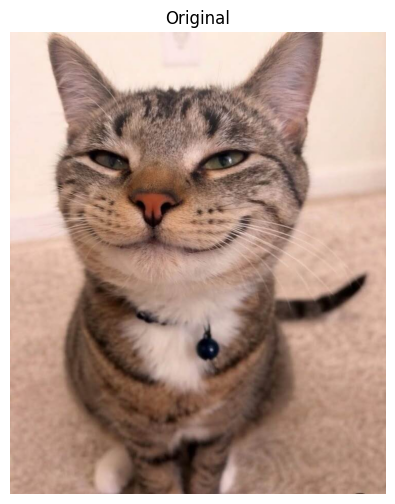

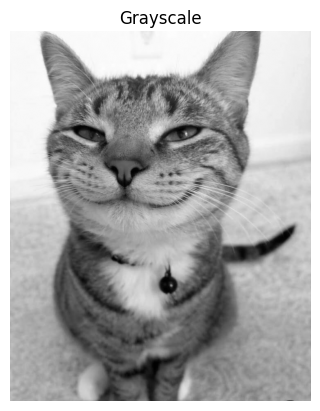

In [5]:
image_path = "image_basic.jpg"
image = cv2.imread(image_path)
print("Shape:", image.shape)

show_bgr(image, "Original")

resized = cv2.resize(image, (224,224))
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale")
plt.show()

## Blur + Edge Detection

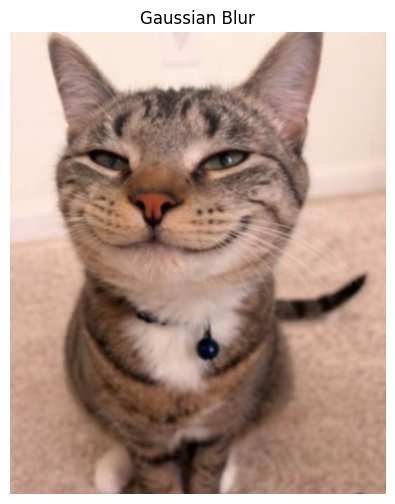

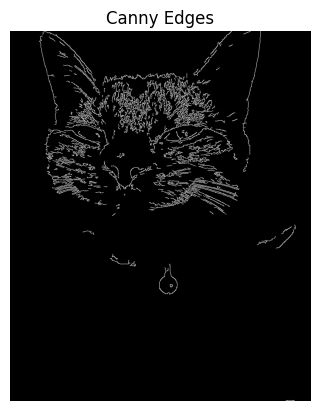

In [6]:
blur = cv2.GaussianBlur(image, (7,7), 0)
edges = cv2.Canny(gray, 100, 200)

show_bgr(blur, "Gaussian Blur")

plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.title("Canny Edges")
plt.show()

## Thresholding + Contours

Contours: 20


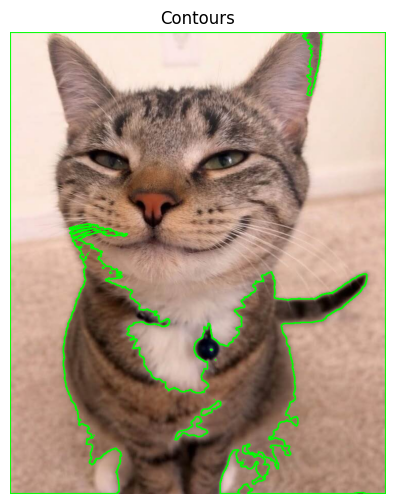

In [7]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = image.copy()
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

print("Contours:", len(contours))
show_bgr(contour_img, "Contours")

## Image Normalization

In [8]:
img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
img_norm = img_rgb.astype("float32") / 255.0
print(img_norm.min(), img_norm.max())

0.0 1.0


## VGG16 Inference

In [9]:
vgg = tf.keras.applications.VGG16(weights="imagenet", include_top=True)
img = cv2.cvtColor(cv2.resize(image, (224,224)), cv2.COLOR_BGR2RGB)
x = np.expand_dims(img, 0)
x = tf.keras.applications.vgg16.preprocess_input(x)
preds = vgg.predict(x, verbose=0)

for _, label, score in tf.keras.applications.vgg16.decode_predictions(preds, top=5)[0]:
    print(label, float(score))

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Egyptian_cat 0.60239577293396
tabby 0.21432919800281525
tiger_cat 0.03913014009594917
lynx 0.008996529504656792
doormat 0.005228960420936346


## ResNet50 Inference

In [10]:
resnet = tf.keras.applications.ResNet50(weights="imagenet", include_top=True)
img = cv2.cvtColor(cv2.resize(image, (224,224)), cv2.COLOR_BGR2RGB)
x = np.expand_dims(img, 0)
x = tf.keras.applications.resnet50.preprocess_input(x)
preds = resnet.predict(x, verbose=0)

for _, label, score in tf.keras.applications.resnet50.decode_predictions(preds, top=5)[0]:
    print(label, float(score))

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Egyptian_cat 0.805997371673584
tabby 0.1749182939529419
tiger_cat 0.015155069530010223
lynx 0.0020792316645383835
Persian_cat 8.81274463608861e-05


## MobileNetV2 Inference

In [11]:
mobilenet = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=True)
img = cv2.cvtColor(cv2.resize(image, (224,224)), cv2.COLOR_BGR2RGB)
x = np.expand_dims(img, 0)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
preds = mobilenet.predict(x, verbose=0)

for _, label, score in tf.keras.applications.mobilenet_v2.decode_predictions(preds, top=5)[0]:
    print(label, float(score))

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Egyptian_cat 0.757892370223999
tabby 0.180487260222435
tiger_cat 0.0289456769824028
lynx 0.001913204207085073
Norwegian_elkhound 0.00040578507469035685


## EfficientNetB0 Inference

In [12]:
efficientnet = tf.keras.applications.EfficientNetB0(weights="imagenet", include_top=True)
img = cv2.cvtColor(cv2.resize(image, (224,224)), cv2.COLOR_BGR2RGB)
x = np.expand_dims(img, 0)
preds = efficientnet.predict(x, verbose=0)

for _, label, score in tf.keras.applications.efficientnet.decode_predictions(preds, top=5)[0]:
    print(label, float(score))

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Egyptian_cat 0.7437625527381897
tabby 0.10355029255151749
lynx 0.05443478748202324
tiger_cat 0.03322572261095047
Siamese_cat 0.002617956604808569


## Transfer Learning — Freeze Base

In [13]:
base = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(224,224,3)
)
base.trainable = False

transfer_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## IoU Function

In [14]:
def iou(boxA, boxB):
    xA, yA = max(boxA[0],boxB[0]), max(boxA[1],boxB[1])
    xB, yB = min(boxA[2],boxB[2]), min(boxA[3],boxB[3])
    inter = max(0,xB-xA) * max(0,yB-yA)
    areaA = max(0,boxA[2]-boxA[0]) * max(0,boxA[3]-boxA[1])
    areaB = max(0,boxB[2]-boxB[0]) * max(0,boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter/union if union else 0

print("IoU:", iou([50,50,200,200], [120,120,260,260]))

IoU: 0.1792717086834734


## NMS

In [15]:
def nms(boxes, scores, threshold=0.5):
    boxes = np.array(boxes, float)
    scores = np.array(scores, float)
    order = scores.argsort()[::-1]
    keep = []
    while len(order):
        i = order[0]
        keep.append(i)
        order = np.array([j for j in order[1:] if iou(boxes[i], boxes[j]) < threshold], dtype=int)
    return keep

boxes = [[50,50,200,200],[60,60,205,205],[180,180,300,300]]
scores = [0.95,0.88,0.72]
print("Keep:", nms(boxes, scores))

Keep: [np.int64(0), np.int64(2)]


## R-CNN Family Memory

In [16]:
print("R-CNN: region proposals -> CNN per region")
print("Fast R-CNN: one CNN feature map -> ROI features")
print("Faster R-CNN: adds Region Proposal Network")

R-CNN: region proposals -> CNN per region
Fast R-CNN: one CNN feature map -> ROI features
Faster R-CNN: adds Region Proposal Network


## YOLO Detection

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

image 1/1 /content/image_detection.jpg: 640x640 6 persons, 3 cars, 1 bus, 1 traffic light, 466.0ms
Speed: 35.7ms preprocess, 466.0ms inference, 36.2ms postprocess per image at shape (1, 3, 640, 640)


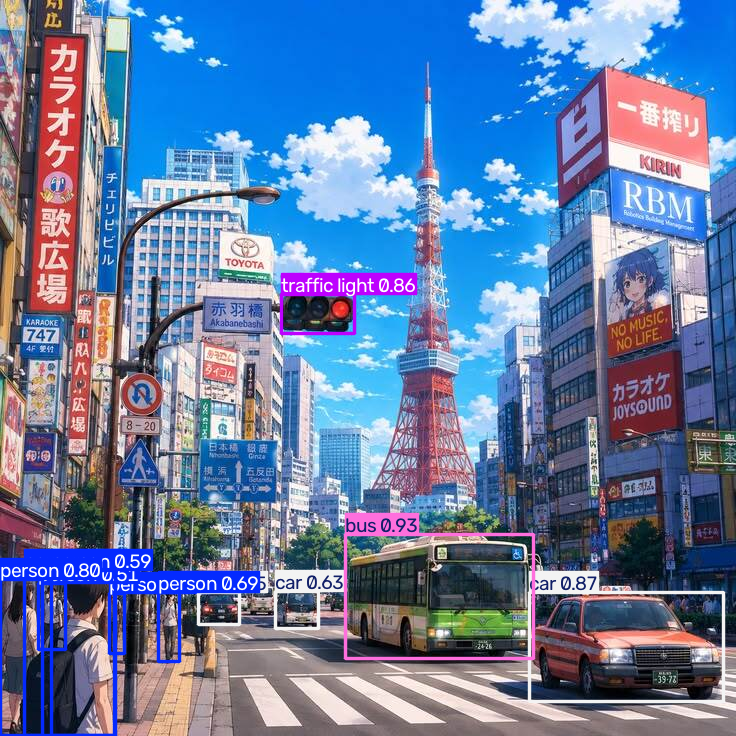

In [17]:
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")
results = yolo("image_detection.jpg")
results[0].show()

## YOLO Result Table

In [18]:
result = results[0]
rows = []
for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].cpu().numpy().tolist()
    rows.append([result.names[cls_id], conf, *xyxy])

pd.DataFrame(rows, columns=["Class","Confidence","x1","y1","x2","y2"])

,Class,Confidence,x1,y1,x2,y2
0,bus,0.925963,345.723389,534.065674,533.540161,658.952820
1,car,0.872803,529.423096,592.820679,723.279114,701.280212
2,traffic light,0.862085,281.047333,294.053284,354.046448,333.264313
3,person,0.804201,0.000000,579.707764,42.104240,735.419312
4,person,0.691950,158.688080,592.585754,179.784714,661.590515
5,car,0.626639,275.214722,591.039246,318.913513,628.509155
6,person,0.587606,51.739754,570.656677,115.039131,735.514038
7,car,0.549483,198.418274,592.759766,239.674072,624.562439
8,person,0.513329,38.351368,583.793335,65.728043,649.912842
9,person,0.327616,109.461716,593.363647,124.331383,653.607239


## Simple U-Net

In [19]:
def conv_block(x, f):
    x = layers.Conv2D(f,3,padding="same",activation="relu")(x)
    x = layers.Conv2D(f,3,padding="same",activation="relu")(x)
    return x

def build_unet(shape=(128,128,3)):
    inp = layers.Input(shape=shape)
    c1 = conv_block(inp,32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1,64); p2 = layers.MaxPooling2D()(c2)
    b = conv_block(p2,128)
    u2 = layers.UpSampling2D()(b); u2 = layers.Concatenate()([u2,c2]); c3 = conv_block(u2,64)
    u1 = layers.UpSampling2D()(c3); u1 = layers.Concatenate()([u1,c1]); c4 = conv_block(u1,32)
    out = layers.Conv2D(1,1,activation="sigmoid")(c4)
    return keras.Model(inp,out)

unet = build_unet()
unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_8[0][0]  

 Total params: 471,553 (1.80 MB)

 Trainable params: 471,553 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

## U-Net Forward Pass

In [20]:
dummy = np.random.rand(1,128,128,3).astype("float32")
mask = unet(dummy)
print("Mask shape:", mask.shape)

Mask shape: (1, 128, 128, 1)


## Simple Segmentation Mask

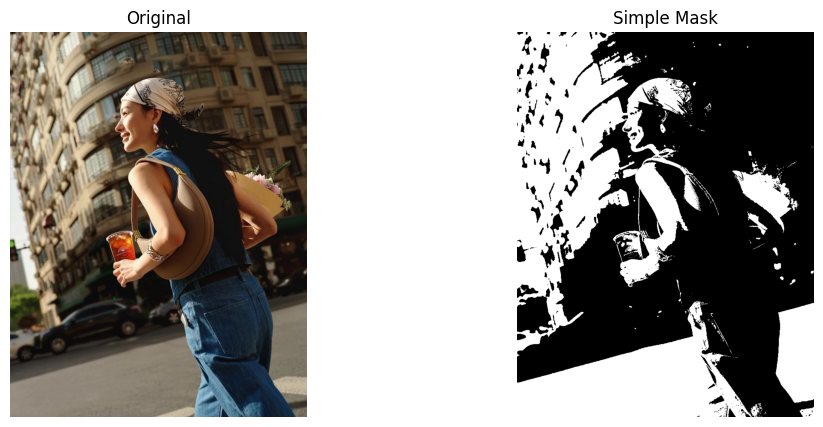

In [21]:
seg = cv2.imread("image_segmentation.jpg")
gray_seg = cv2.cvtColor(seg, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray_seg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray"); plt.axis("off"); plt.title("Simple Mask")
plt.show()

## ViT Patch Extraction

In [22]:
vit_path = "image_vit.jpg" if os.path.exists("image_vit.jpg") else image_path
vit = cv2.cvtColor(cv2.resize(cv2.imread(vit_path), (224,224)), cv2.COLOR_BGR2RGB)

patch_size = 16
patches = []
for y in range(0,224,patch_size):
    for x in range(0,224,patch_size):
        patches.append(vit[y:y+patch_size, x:x+patch_size])

patches = np.array(patches)
print("Patch count:", len(patches))
print("Patch shape:", patches[0].shape)

Patch count: 196
Patch shape: (16, 16, 3)


## Visualize ViT Patches

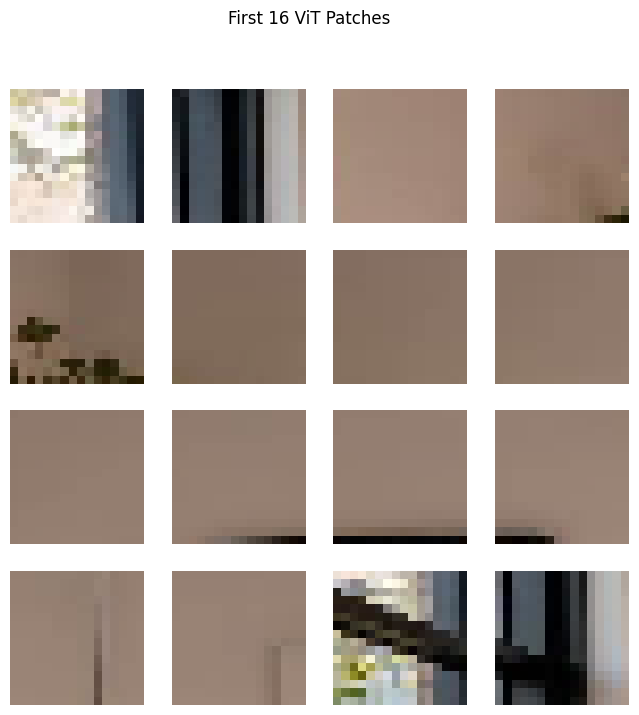

In [23]:
fig, axes = plt.subplots(4,4, figsize=(8,8))
for i, ax in enumerate(axes.flat):
    ax.imshow(patches[i])
    ax.axis("off")
plt.suptitle("First 16 ViT Patches")
plt.show()

## Patch Embedding + Self Attention

In [24]:
patch_dim = 16*16*3
flat = patches.reshape(len(patches), patch_dim).astype("float32") / 255.0

projection = layers.Dense(64)
embedded = projection(flat)

x = tf.expand_dims(embedded, 0)
mha = layers.MultiHeadAttention(num_heads=4, key_dim=16)
attn_out = mha(x, x)

print("Embedded:", embedded.shape)
print("Attention output:", attn_out.shape)

Embedded: (196, 64)
Attention output: (1, 196, 64)


## Final Summary

In [25]:
pd.DataFrame({
    "Topic":["OpenCV","Transfer Learning","VGG16","ResNet","MobileNet","EfficientNet","R-CNN","Fast R-CNN","Faster R-CNN","YOLO","IoU","NMS","U-Net","ViT"],
    "Memory Point":["Image processing","Reuse pretrained features","3x3 conv stacks","Skip connections","Lightweight","Compound scaling","CNN per region","Shared feature map","RPN","One-stage detection","Overlap","Remove duplicates","Encoder-decoder skips","Patches + transformer"]
})

,Topic,Memory Point
0,OpenCV,Image processing
1,Transfer Learning,Reuse pretrained features
2,VGG16,3x3 conv stacks
3,ResNet,Skip connections
4,MobileNet,Lightweight
5,EfficientNet,Compound scaling
6,R-CNN,CNN per region
7,Fast R-CNN,Shared feature map
8,Faster R-CNN,RPN
9,YOLO,One-stage detection
